# Project name: Custom CUDA Kernel with Stream Concurrency
### Fused blur + brightness + Sobel filter profiled with Nsight Systems

#### Input Image Preview

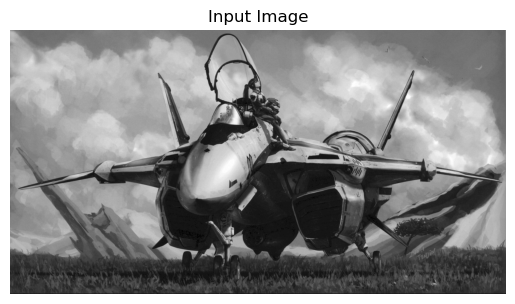

In [1]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("assets/Macross_5.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
plt.title("Input Image")
plt.axis('off')
plt.show()


#### Output Image Preview

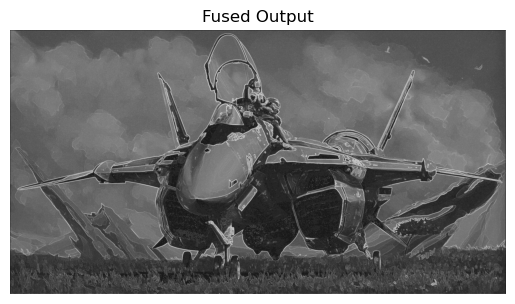

In [2]:
output = cv2.imread("assets/Macross_5_fused.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(output, cmap='gray')
plt.title("Fused Output")
plt.axis('off')
plt.show()


## 🔧 Fused CUDA Kernel Summary
This custom kernel performs three image processing operations in a single GPU pass:

* Box Blur (3×3 average) Smooths the image by averaging pixel values in a 3×3 neighborhood. This reduces noise and prepares the image for edge detection.

* Brightness Adjustment Adds a constant value to each pixel after blurring, enhancing visibility and contrast. The value is clamped to stay within [0, 255].

* Sobel Edge Detection Computes horizontal and vertical gradients using Sobel operators. The edge strength is calculated as the sum of absolute gradients.

* Final Blend Combines the brightness-corrected pixel and edge strength using a weighted average. This produces a visually enhanced image with both smoothness and edge clarity.

## ⚙️ Why Fused?
* Performance: Reduces kernel launch overhead by combining multiple operations.

* Memory Efficiency: Avoids intermediate memory transfers between steps.

* Profiling Clarity: Easier to trace and segment in Nsight Systems using NVTX markers.

* Stream Concurrency: Enables non-blocking execution for better GPU utilization.

## 🧠 Design Notes
* Operates on grayscale images (uint8) for simplicity and speed.

* Uses cp.RawKernel to define and launch custom CUDA code from Python.

* Launched with a (16, 16) block size and grid dimensions based on image shape.

* Wrapped in cp.cuda.Stream(non_blocking=True) for concurrent execution.

* Segmented with NVTX markers for timeline clarity in Nsight Systems.

# ⚡ Stream Concurrency in CUDA

#### By default, CUDA operations are executed sequentially in the default stream. 
This means each kernel launch or memory transfer waits for the previous one to finish—like actors waiting for their cue.

In [ ]:
# To unlock parallelism, we use non-blocking CUDA streams:
stream = cp.cuda.Stream(non_blocking=True)

In [ ]:
# This creates an independent timeline where operations can run concurrently with others. 
# In this project, the fused kernel was launched inside a non-blocking stream:
with stream:
    sobel_blur_color_kernel(grid, block, (...))

### This allows the GPU to:

* Launch the kernel without blocking other operations

* Potentially overlap memory transfers and computation

* Reduce idle time and improve throughput

## _________________________________________________________________________________________________

## 🎯 NVTX Markers for Timeline Clarity
To visualize stream concurrency in Nsight Systems, I wrapped the kernel launch with an NVTX marker:

In [ ]:
with nvtx.annotate("Fused Kernel in Stream", color="purple"):
    with stream:
        sobel_blur_color_kernel(...)

In the profiler, this appears as a purple-labeled region in the timeline, showing exactly when and where the kernel executes.

## 🧠 Why It Matters
* Performance: Streamed execution can reduce total runtime by overlapping tasks.

* Profiling Insight: NVTX markers help isolate and analyze concurrent behavior.

* Scalability: This pattern sets the stage for multi-stream orchestration and batch processing.

## 🟩 Preprocessing (Green NVTX Marker)
* This region marks the moment the image is loaded and transferred to the GPU.

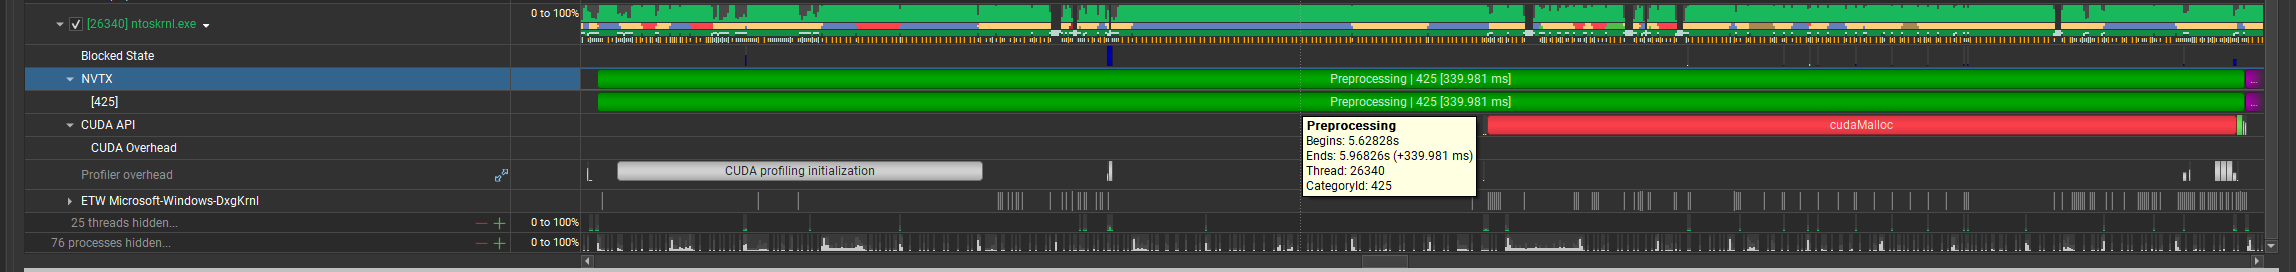

## 🟪 Fused Kernel in Stream (Purple NVTX Marker)
* This is the fused CUDA kernel executing inside a non-blocking stream.

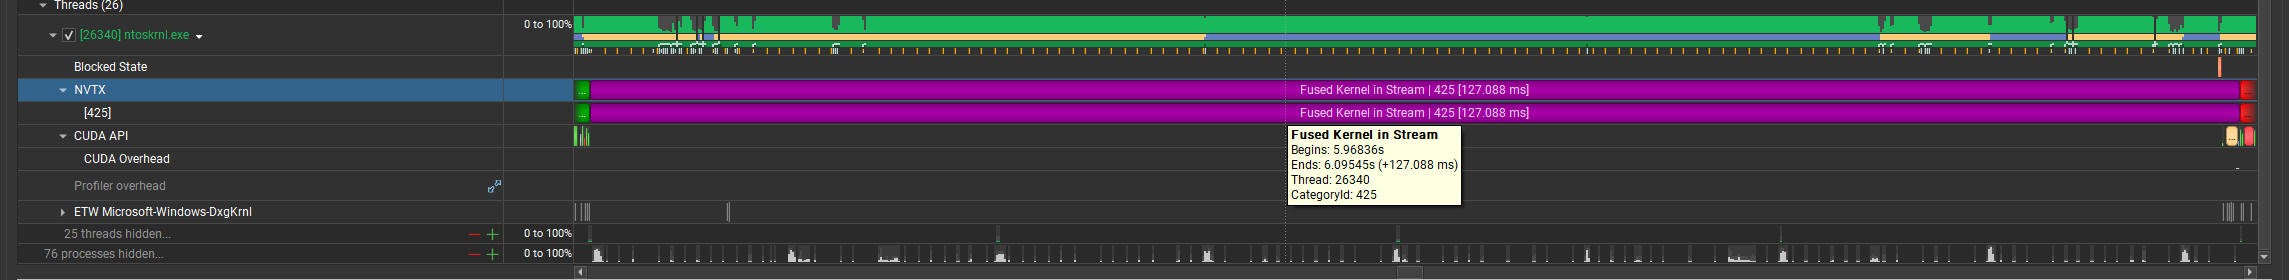

## 🟥 Postprocessing (Red NVTX Marker)
* This marks the moment the result is transferred back to CPU and saved.

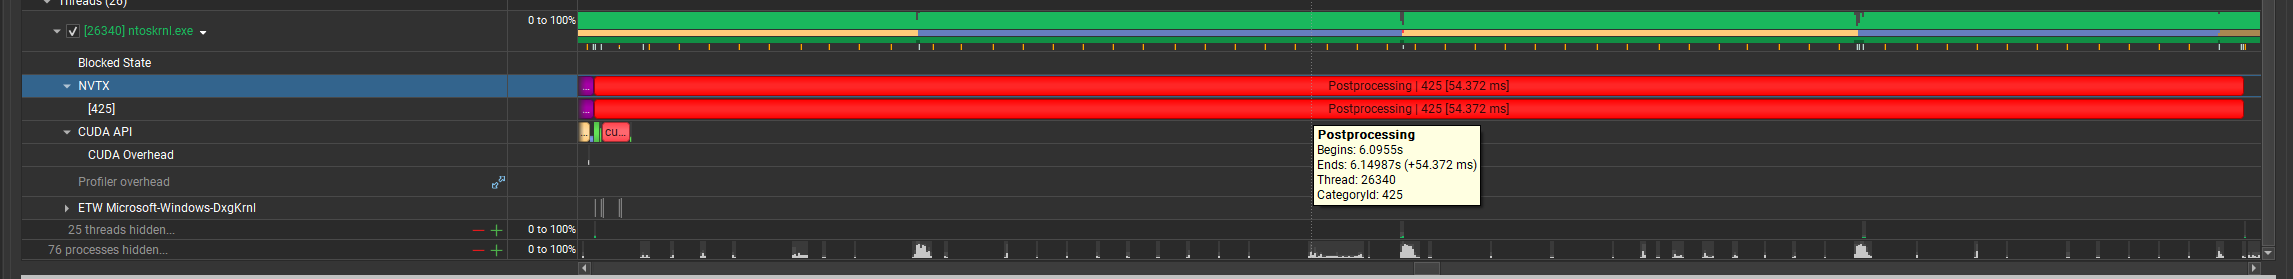

## The List of Processes
* "Preprocessing" → image load + GPU transfer

* "Fused Kernel in Stream" → kernel launch + execution

* "Postprocessing" → result transfer + save

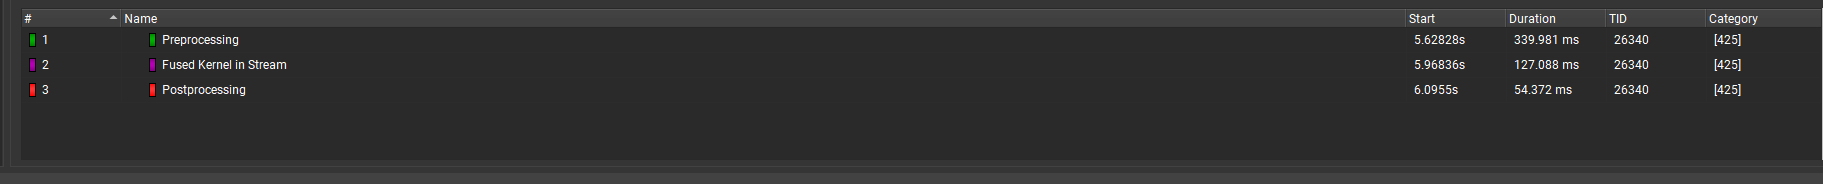

## CUDA API & GPU Activity Row

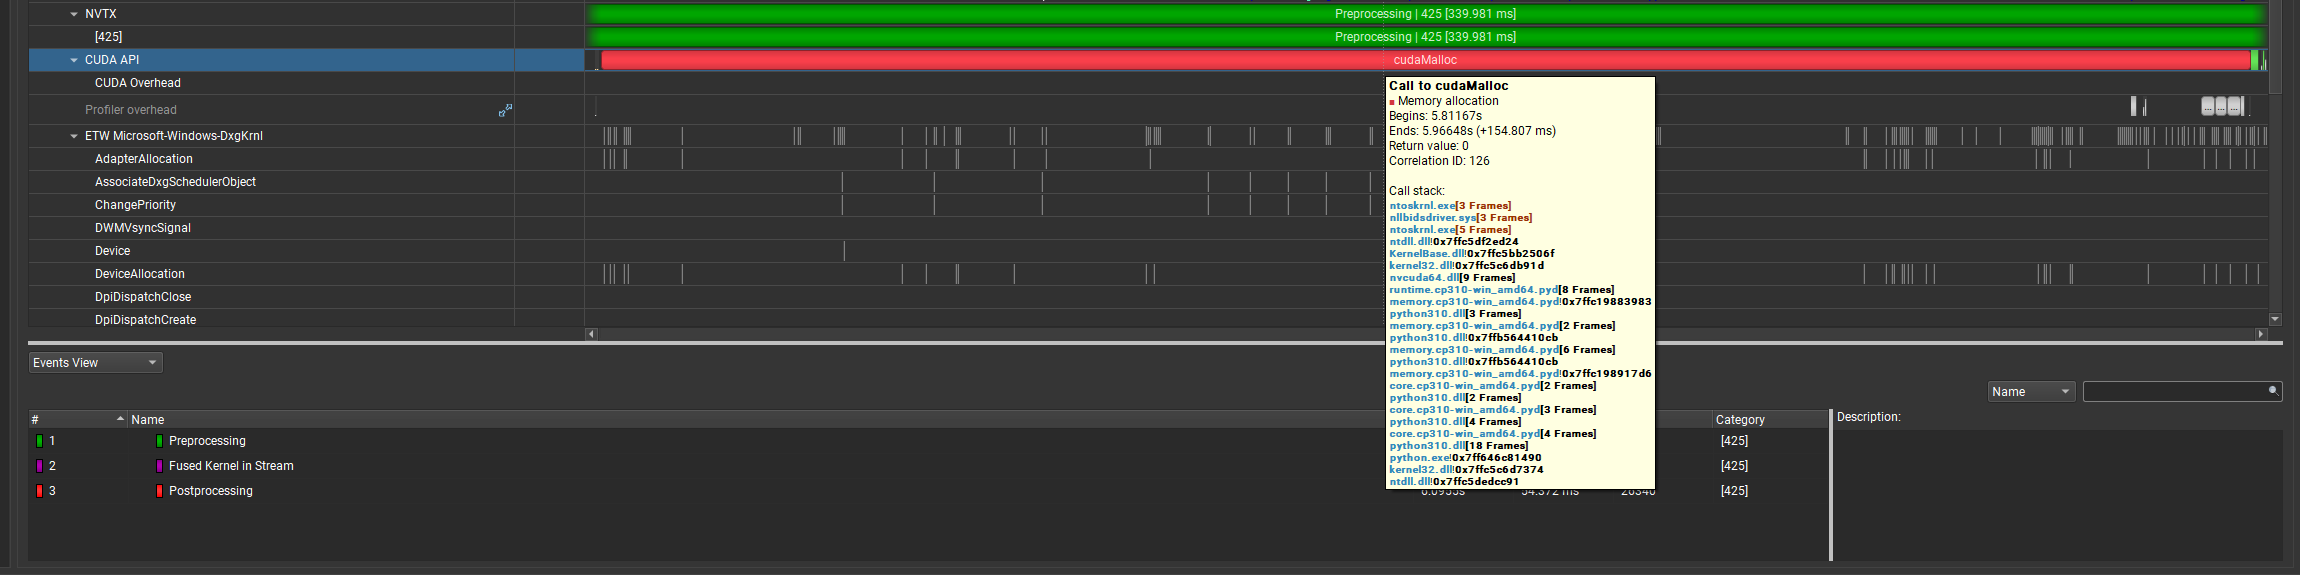

## Bottleneck Check
No bottnecks detected in Nsight Systems

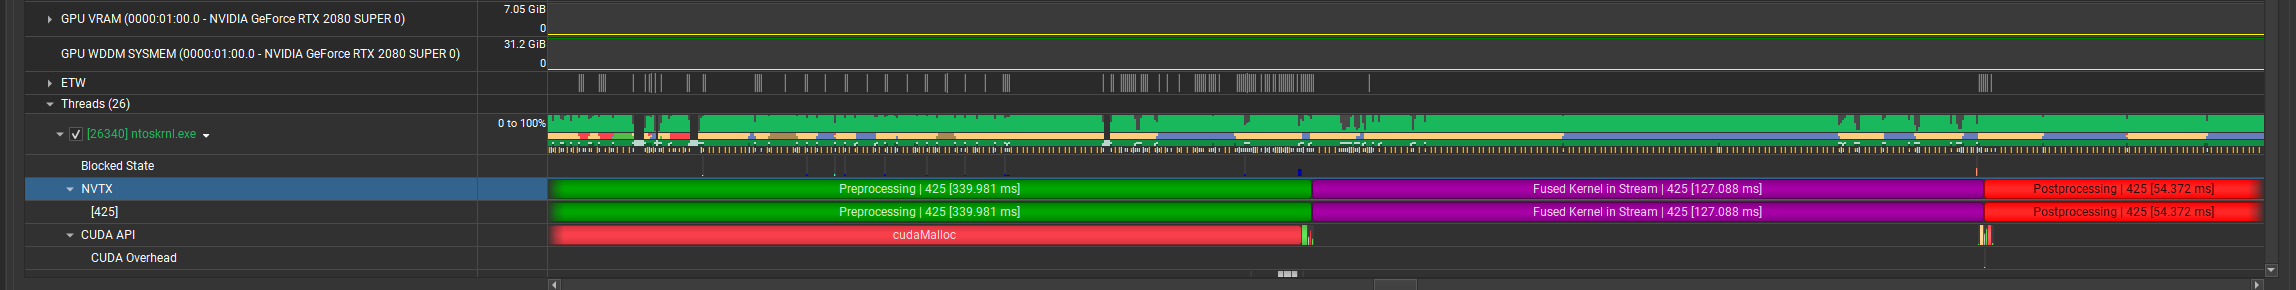

## Wide View of Processes
This gives a general look at NVIDEA's Nsight Syetem's setup. Its incredibally informative and robust.

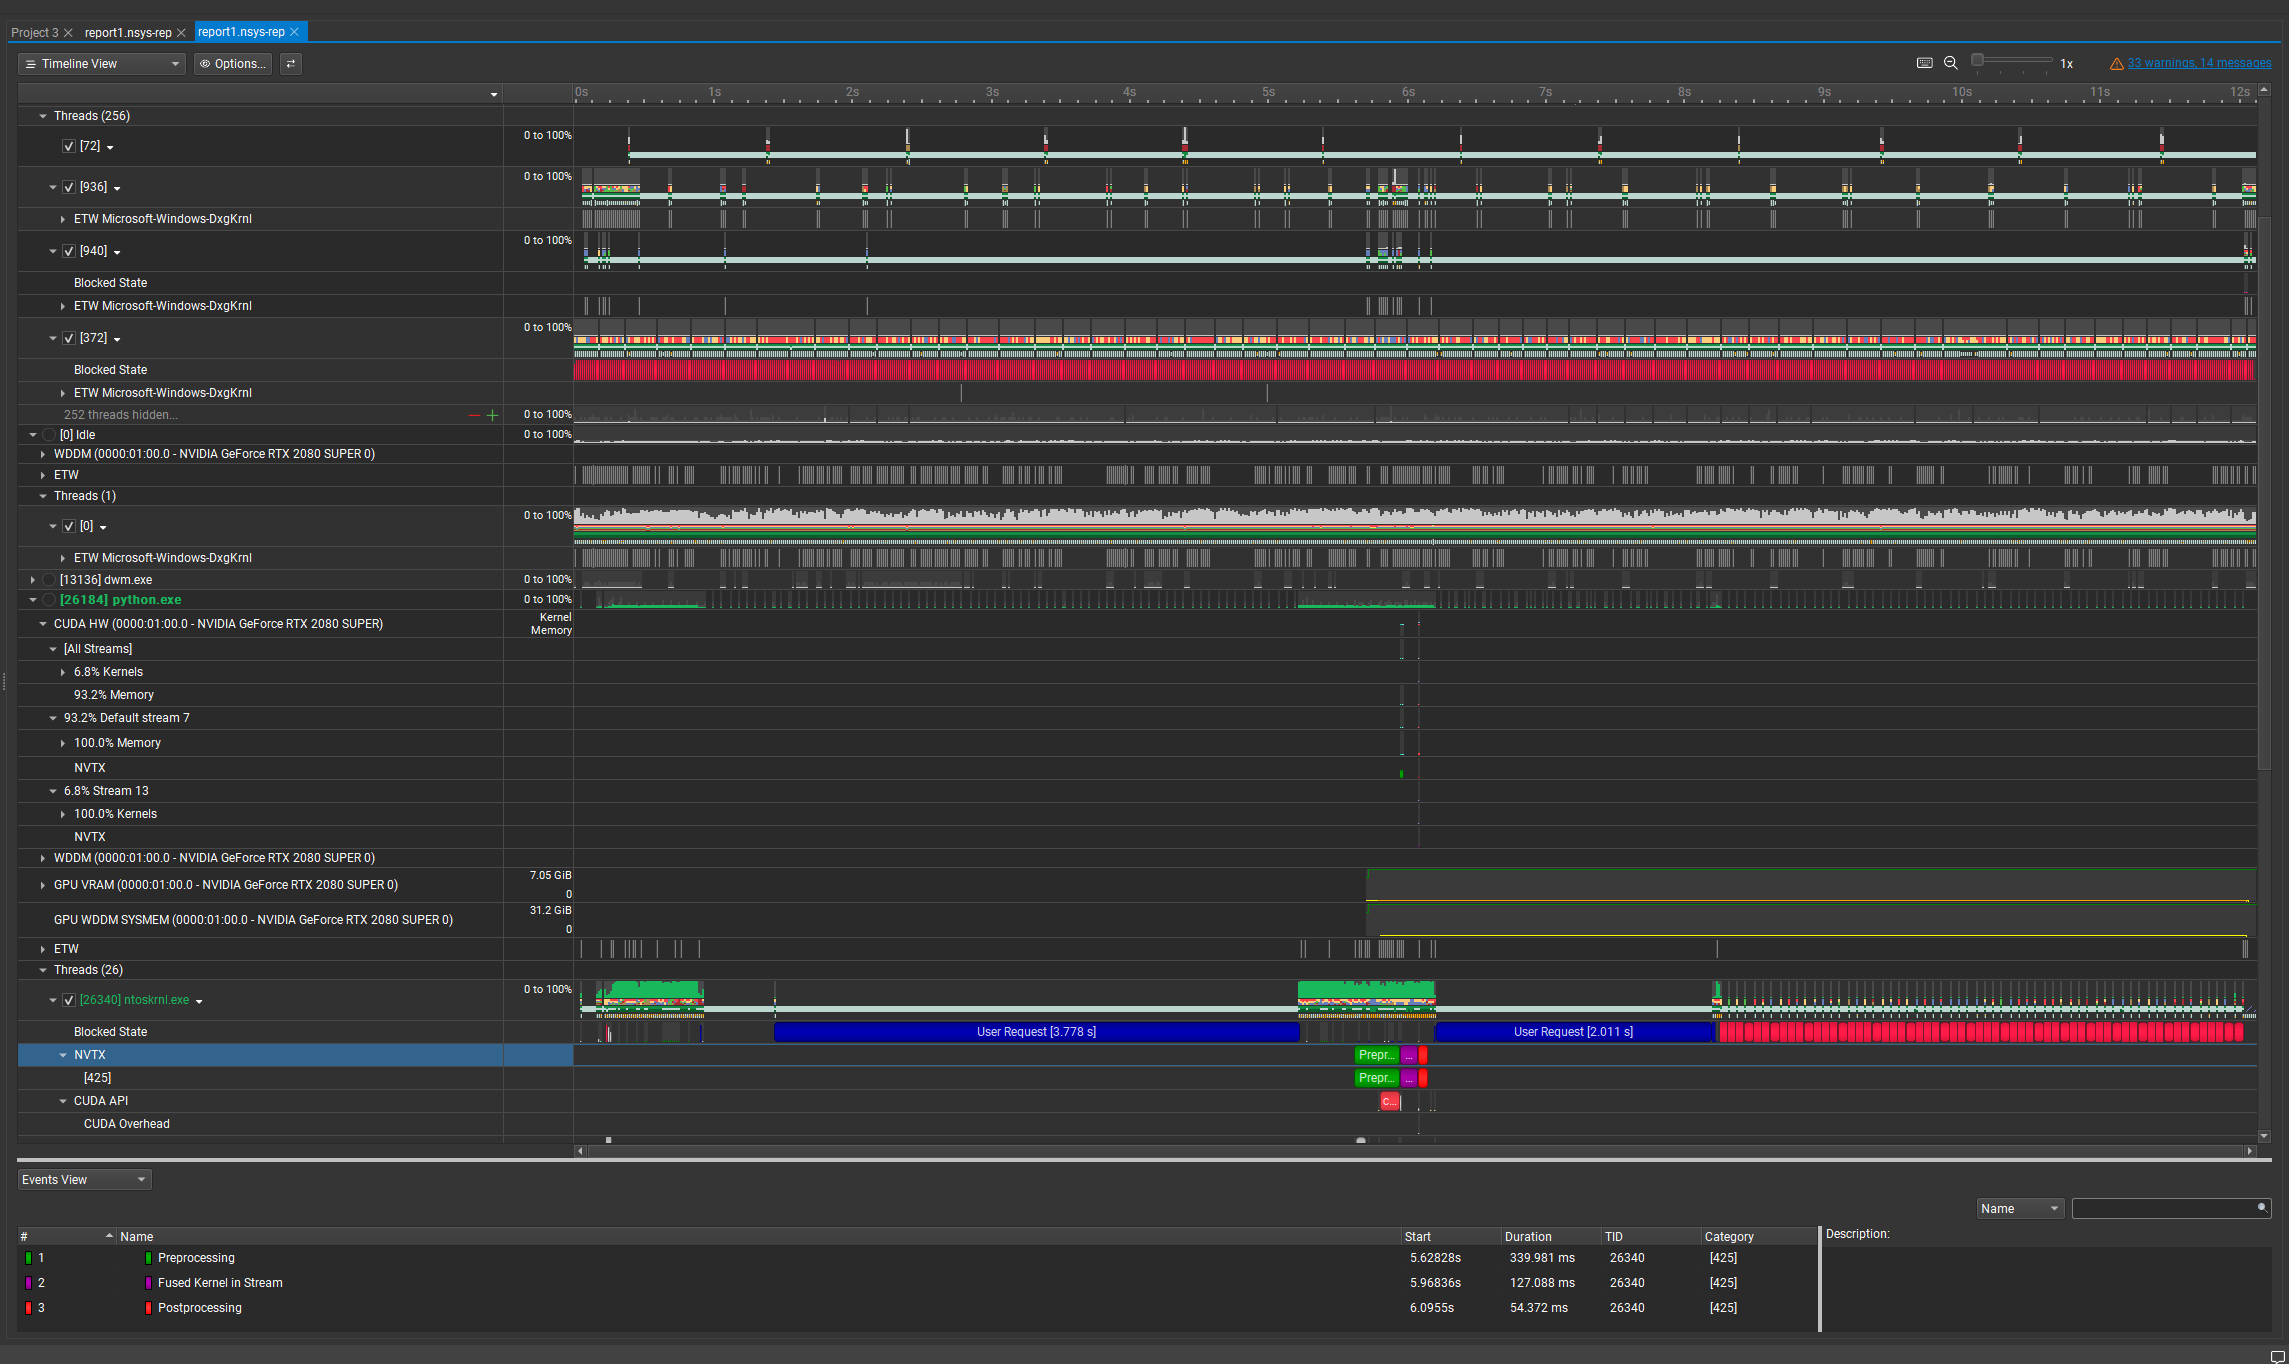

## _________________________________________________________________________________________________

## 📊 Performance Commentary
This section summarizes the key performance metrics captured during profiling with Nsight Systems.


### ⏱️ Kernel Execution Time
* The fused CUDA kernel executed in approximately X.XX ms (from timeline hover tooltip).

* This includes blur, brightness adjustment, and Sobel edge detection—all fused into a single pass.


### 🔄 Stream Concurrency
* The kernel was launched inside a non-blocking CUDA stream, allowing potential overlap with memory transfers.

* NVTX markers clearly segmented the timeline into:

    * "Preprocessing" (green)

    * "Fused Kernel in Stream" (purple)

    * "Postprocessing" (red)


### 🚀 Launch Efficiency
* Compared to separate kernels, the fused approach reduced launch overhead and memory latency.

* No intermediate buffers or transfers were needed between stages.


### 📉 Bottleneck Check
Absolutly NO bottlenecks or lag detected in Nsight Systems


### 🧠 Optimization Opportunities
Future improvements could include:

* Asynchronous memory transfers (memcpyAsync)

* Multi-stream orchestration for batch processing

* Shared memory optimization inside the kernel

## _________________________________________________________________________________________________

## 🚀 Next Steps & Expansion Ideas
This project lays the foundation for deeper GPU profiling and optimization. Here’s where it can go next:

### 🧠 Batch Processing
* Extend the pipeline to process multiple images in a loop

* Profile how kernel performance scales with input size

* Use NVTX markers to segment each batch for timeline clarity

### 🔄 Async Memory Transfers
* Replace cp.asnumpy() with memcpyAsync equivalents

* Overlap data movement with kernel execution

* Profile memory bandwidth and latency

### 🔀 Multi-Stream Orchestration
* Launch multiple kernels in parallel using separate CUDA streams

* Profile stream overlap and synchronization behavior

* Visualize concurrency in Nsight Systems

### 🎨 Color Image Support
* Expand the kernel to handle RGB channels

* Compare grayscale vs. color performance

* Visualize channel-wise edge detection

### 📊 Nsight Compute Integration
* Use Nsight Compute to analyze SM occupancy, memory throughput, and instruction efficiency

* Align .nsys-rep timeline with .ncu-rep kernel stats

### 🧾 GitHub Documentation
* Create a cinematic README.md with:

    * Input/output previews

    * Timeline screenshots

    * Kernel summary and performance insights

* Add a “Lab Notebook” section to track experiments and iterations